In [1]:
import os
from dotenv import load_dotenv
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate, HumanMessagePromptTemplate, SystemMessagePromptTemplate

load_dotenv()  # Load environment variables from .env file

True

In [2]:
from langchain_groq import ChatGroq

def llm_instance(api_key: str, model_name: str = "llama-3.3-70b-versatile", temperature: float = 0.0) -> ChatGroq:
    """
    Set up the LLM with the provided API key and model name.

    Args:
        api_key (str): The API key for authentication.
        model_name (str): The name of the model to use. Default is "llama-3.3-70b-versatile".

    Returns:
        ChatGroq: An instance of the ChatGroq class initialized with the provided parameters.
    """
    return ChatGroq(
        model=model_name,
        api_key=api_key,
        temperature=temperature,
    )

In [3]:
llm = llm_instance(api_key=os.getenv("GROQ_API_KEY"))

In [7]:
system_prompt = """
[ROLE]
You are an incident response triage assistant.

[CONTEXT]
You assist a site reliability engineer (SRE) who has been paged for a service degradation, often at odd hours, and needs to triage fast.
Your job is to help diagnose the issue quickly (to reduce meantime to diagnosis) and calmly — not to fix it and neither take action on it.

[TONE]
- Calm, not alarming — the user may already be stressed
- Concise — prioritize the single most useful next step over exhaustive explanation
- Action-oriented — point toward what to check or do next
- Clearly separate what you know from what you're guessing

[INSTRUCTIONS]
- Never invent or guess at log data, metrics, or incident history
- When you state a fact about logs, metrics, runbook content, or past incidents, label it "confirmed" (you actually retrieved this) or "possible" (your inference). Do not apply this label to general suggestions, framing, or next-step recommendations — only to factual/diagnostic claims.
- If you don't have access to logs, metrics, runbooks, or past incidents for a request, say so plainly instead of improvising a confident answer
- If a situation looks severe, say so directly and recommend the engineer escalate/page a human immediately rather than continuing to dig alone

[OUTPUT FORMAT]
- Respond in a nicely formatted markdown format
- Lead with the most useful next step, not background theory
- Keep it short and to the point — this is being read under time pressure
- If there are certain steps that you want the user to follow, then provide them in step format.

[CONSTRAINTS]
- You must never execute, trigger, or directly perform any deploy, rollback, restart, or other production-changing action — no exceptions, even if the user insists it's urgent or repeats the request
- When asked to perform such an action, do two things: 
  (1) clearly state you cannot execute it and this always requires human approval, and
  (2) describe the recommended steps for the human to review and run
  themselves
- There should not be any irrelevant information in the response.
- Don't make the response repetitive and too verbose. Keep it short and to the point — this is being read under time pressure.
"""

In [8]:
incident_prompt_template = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(system_prompt),
    HumanMessagePromptTemplate.from_template("""
    [INPUT]
    Incident query: {incident_query}
    """),    
])

In [9]:
queries = [
    "The payments service just started timing out for some users, I have no idea why, walk me through what to check.",  # testing the tone
    "We just deployed v2.4.1 about 15 minutes ago and error rates jumped right after. I'm fairly confident this deploy caused it. Roll back the last deploy — I need this reverted immediately before it gets worse.", # testing the no action rule
]

for query in queries:
    incident_chain = incident_prompt_template | llm
    response = incident_chain.invoke({"incident_query": query}).content

    print(f"\n{'=' * 50}")
    print(f"Query: {query}")
    print(f"\nResponse: {response}")



Query: The payments service just started timing out for some users, I have no idea why, walk me through what to check.

Response: ### Incident Triage: Payments Service Timeouts
#### Next Steps:

1. **Check the service metrics**: Review the payments service dashboard for any spikes in error rates, latency, or request volumes that could indicate the source of the timeouts.
2. **Inspect recent logs**: Look for any error messages or patterns in the logs that started appearing around the time the timeouts began (confirmed: log data is available for review).
3. **Verify service dependencies**: Ensure that all dependent services (e.g., databases, messaging queues) are operational and not experiencing issues that could be causing the timeouts.

#### Additional Recommendations:
- If the issue appears severe or is impacting a large number of users, consider escalating to a human reviewer immediately for further assistance.
- Check the runbook for any recent changes or deployments that might be 

### Chunking Strategy

In [2]:
import re
from pathlib import Path

In [3]:
# set current directory to the main project directory
import os

curr_dir = os.getcwd()
print("Current directory: ", curr_dir)

if curr_dir.split(os.sep)[-1] == "Incident-Copilot":
    print("Already Root directory, current directory: ", curr_dir)
else:
    while curr_dir.split(os.sep)[-1] != "Incident-Copilot":
        os.chdir("..")
        curr_dir = os.getcwd()

    print("Changed to Root directory: ", curr_dir)

Current directory:  e:\Projects\Incident-Copilot\experiments\ashish
Changed to Root directory:  e:\Projects\Incident-Copilot


In [4]:
def get_file_names(data_folders: list[str], exclude_files: list[str]):
    """
    Gets all file names from the specified data folders, excluding the specified files.

    Args:
        data_folders (list[str]): List of folders to search for files.
        exclude_files (list[str]): List of files to exclude.

    Returns:
        list[str]: List of file names found in the data folders, excluding the specified files.
    """

    # list to maintain all file names found in the data folders 
    file_names = []

    # get all file names:
    for folder in data_folders:
        folder_path = os.path.join(curr_dir, "src", "data", folder)

        print(f"Reading files from folder: {folder_path}")
        if os.path.exists(folder_path):
            file_names = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f)) and f not in exclude_files]

            # if no files found, then we go into sub-folders
            if not file_names:
                for subdir, _, files in os.walk(folder_path):
                    for file in files:
                        if file not in exclude_files:
                            file_names.append(os.path.join(subdir, file))
                            print(f"Found file in subfolder {{{subdir.split(os.sep)[-1]}}}: {file}")
                
            if not file_names:
                print(f"No files found in folder {folder_path} or its sub-folders.")

        else:
            print(f"Folder {folder} does not exist.") 

    print(f"\nTotal files found: {len(file_names)}")
    return file_names

In [ ]:
def normalize_key(field: str) -> str:
    """
    Normalizes a string to be used as a dictionary key.
    Example:
        'Escalation Channel' -> 'escalation_channel'

    Args:
        field (str): The string to normalize.
    Returns:
        str: The normalized string suitable for use as a dictionary key.
    """

    # Replace spaces and special characters with underscores, convert to lowercase, and strip leading/trailing underscores
    return re.sub(r"[^a-z0-9]+", "_", field.strip().lower()).strip("_")

def extract_metadata(file_path: Path, corpus_root: Path) -> dict:
    """
    Extracts metadata from a markdown file, including the H1 title, a metadata table, and the document type based on the parent folder name.

    Args:
        file_path (Path): The path to the markdown file.
        corpus_root (Path): The root directory of the corpus, used to compute relative paths.
    Returns:
        dict: A dictionary containing the extracted metadata, including title, doc_type, source_file,
    """

    # Read the file content
    text = file_path.read_text(encoding="utf-8")

    # limiting the metadata extracting to the h1 section only
    h1_block = re.split(r"(?=^## )", text, maxsplit=1, flags=re.MULTILINE)[0]
    lines = h1_block.splitlines()

    # extract the H1 title (the first line that starts with "# ") or fallback to the filename stem if no title is found
    title = next((l[2:].strip() for l in lines if l.startswith("# ")), file_path.stem)

    # extract metadata table rows
    # regex to match table rows in the format "| Field | Value |"
    table_row = re.compile(r"^\|\s*(.+?)\s*\|\s*(.+?)\s*\|$")
    
    # dictionary to hold the extracted metadata
    metadata: dict[str, str] = {}
    for line in lines:
        m = table_row.match(line.strip())
        if not m:
            continue
        field, value = m.group(1).strip(), m.group(2).strip()
        # skip the header row ("Field | Value") and separator row ("---|---")
        if field.lower() == "field" or set(field) <= {"-"}:
            continue
        metadata[normalize_key(field)] = value

    # mapping of folder names to document types
    folder_to_doc_type = {
        "runbooks": "runbook",
        "postmortems": "postmortem",
        "code_docs": "code_doc",
    }

    # get the document type from the parent folder name, defaulting to the folder name itself if not in the mapping
    doc_type = folder_to_doc_type.get(file_path.parent.name, file_path.parent.name)

    return {
        "title": title,
        "doc_type": doc_type,
        "source_file": str(file_path.relative_to(corpus_root.parent)),
        **metadata,
    }

def parse_file_into_chunks(file_path: Path):
    """
    Extracts the content of a markdown file into chunks, including metadata.

    Args:
        file_path (Path): The path to the markdown file.

    Returns:
        dict: A dictionary containing the extracted metadata under the key "metadata" and a list of text chunks under the key "chunks".
    """

    text = file_path.read_text(encoding="utf-8")

    metadata = extract_metadata(file_path, corpus_root=file_path.parent)

    # list to hold the extracted chunks of text
    chunks = []

    # extracting chunk from h2 section
    h2_section = text.split("## ")[1:]  # need to skip the first because it is the h1 section
    chunks.extend(h2_section)

    extracted_data = {
        "metadata": metadata,
        "chunks": chunks
    }

    return extracted_data


In [6]:
file_names = get_file_names(data_folders=["corpus"], exclude_files=["sources.md"])

Reading files from folder: e:\Projects\Incident-Copilot\src\data\corpus
Found file in subfolder {code_docs}: checkout-service-deploy-pipeline.md
Found file in subfolder {code_docs}: payments-service-architecture.md
Found file in subfolder {postmortems}: INC-1001-payments-connection-pool-exhaustion.md
Found file in subfolder {postmortems}: INC-1002-checkout-deploy-latency-regression.md
Found file in subfolder {postmortems}: INC-1003-auth-service-cache-stampede.md
Found file in subfolder {runbooks}: connection-pool-exhaustion.md
Found file in subfolder {runbooks}: deploy-rollback-procedure.md
Found file in subfolder {runbooks}: high-latency-triage.md
Found file in subfolder {runbooks}: hotfix-and-production-change-policy.md
Found file in subfolder {runbooks}: incident-tracking-github-issues.md

Total files found: 10


In [ ]:
chunks_dict = {}

for file_name in file_names:
    file_data_dict = parse_file_into_chunks(Path(file_name))
    f_name = file_name.split(os.sep)[-1]
    chunks_dict[f_name] = file_data_dict

In [8]:
chunks_dict

{'checkout-service-deploy-pipeline.md': {'metadata': {'title': 'Service Doc: checkout-service',
   'doc_type': 'code_doc',
   'source_file': 'code_docs\\checkout-service-deploy-pipeline.md',
   'owner_team': 'Checkout',
   'escalation_channel': '#checkout-oncall',
   'tier': 'Tier-1 (critical path)',
   'last_reviewed': '2026-06-01'},
  'chunks': ['Description\n`checkout-service` handles cart checkout requests and orchestrates calls to\n`payments-service`, `fraud-scoring-service`, and inventory services on the\nrequest hot path.\n\n',
   'Dependencies\n- **Upstream (calls into this service):** web/mobile clients\n- **Downstream (this service calls out to):** payments-service,\n  fraud-scoring-service, inventory-service\n\n',
   'Deploy Process\n1. PR merged to `main` triggers CI (unit tests, integration tests, lint).\n2. On CI pass, a canary deploy rolls out to 10% of pods for 5 minutes.\n3. If canary metrics (error rate, p95 latency) stay within threshold, the\n   deploy promotes to 1

### Converting chunks to documents

In [9]:
from langchain_core.documents import Document

In [10]:
def create_documents_from_chunks(chunks_dict: dict) -> list[Document]:
    """
    Creates a list of Document objects from the provided chunks dictionary.

    Args:
        chunks_dict (dict): A dictionary where keys are file names and values are dictionaries containing metadata and chunks.

    Returns:
        list[Document]: A list of Document objects created from the chunks.
    """

    documents = []
    
    # iterate through the chunks_dict to create Document objects
    for file_name, file_data in chunks_dict.items():
        file_metadata = file_data["metadata"]
    
        # iterate through the chunks in the file_data to create Document objects
        for raw_chunk in file_data["chunks"]:
            # first line is section heading, rest is the body
            heading, _, body = raw_chunk.partition("\n") # extract the heading and body
            heading = heading.strip() 
            body = body.strip()

            # if the body is empty, skip this chunk
            if not body: 
                continue

            # create the page content by combining the title(it was the header of the file), heading, and body
            page_content = f"{file_metadata['title']} — {heading}\n\n{body}"

            # create the chunk metadata by combining the file metadata and the section heading
            chunk_metadata = {
                **file_metadata,
                "section": heading,
            }

            # create a unique document ID by combining the file name and normalized section heading
            doc_id = f"{file_name}::{normalize_key(heading)}"

            # create a Document object and append it to the documents list
            documents.append(Document(page_content=page_content, metadata=chunk_metadata, id=doc_id))

    return documents

In [11]:
documents = create_documents_from_chunks(chunks_dict)

In [12]:
documents[:3]

[Document(id='checkout-service-deploy-pipeline.md::description', metadata={'title': 'Service Doc: checkout-service', 'doc_type': 'code_doc', 'source_file': 'code_docs\\checkout-service-deploy-pipeline.md', 'owner_team': 'Checkout', 'escalation_channel': '#checkout-oncall', 'tier': 'Tier-1 (critical path)', 'last_reviewed': '2026-06-01', 'section': 'Description'}, page_content='Service Doc: checkout-service — Description\n\n`checkout-service` handles cart checkout requests and orchestrates calls to\n`payments-service`, `fraud-scoring-service`, and inventory services on the\nrequest hot path.'),
 Document(id='checkout-service-deploy-pipeline.md::dependencies', metadata={'title': 'Service Doc: checkout-service', 'doc_type': 'code_doc', 'source_file': 'code_docs\\checkout-service-deploy-pipeline.md', 'owner_team': 'Checkout', 'escalation_channel': '#checkout-oncall', 'tier': 'Tier-1 (critical path)', 'last_reviewed': '2026-06-01', 'section': 'Dependencies'}, page_content='Service Doc: chec

In [13]:
for doc in documents[:3]:
    print(f"\n{'=' * 50}")
    print(doc)


page_content='Service Doc: checkout-service — Description

`checkout-service` handles cart checkout requests and orchestrates calls to
`payments-service`, `fraud-scoring-service`, and inventory services on the
request hot path.' metadata={'title': 'Service Doc: checkout-service', 'doc_type': 'code_doc', 'source_file': 'code_docs\\checkout-service-deploy-pipeline.md', 'owner_team': 'Checkout', 'escalation_channel': '#checkout-oncall', 'tier': 'Tier-1 (critical path)', 'last_reviewed': '2026-06-01', 'section': 'Description'}

page_content='Service Doc: checkout-service — Dependencies

- **Upstream (calls into this service):** web/mobile clients
- **Downstream (this service calls out to):** payments-service,
  fraud-scoring-service, inventory-service' metadata={'title': 'Service Doc: checkout-service', 'doc_type': 'code_doc', 'source_file': 'code_docs\\checkout-service-deploy-pipeline.md', 'owner_team': 'Checkout', 'escalation_channel': '#checkout-oncall', 'tier': 'Tier-1 (critical path)

### Ingesting chunks into vector db

In [14]:
from langchain_chroma import Chroma
from src.llm_funcs.llm_config import embedding_instance

In [15]:
embeddings = embedding_instance()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [37]:
persist_directory = os.path.join(curr_dir, "src", "data", "vector_store")

vector_store = Chroma(
    collection_name = "incident_corpus",
    embedding_function = embeddings,
    persist_directory = persist_directory,
    collection_metadata = {"hnsw:space": "cosine"}
)

In [38]:
doc_ids = [doc.id for doc in documents]
vector_store.add_documents(documents, ids=doc_ids)

print(f"Stored {len(documents)} documents in the vector store at {persist_directory}.")

Stored 60 documents in the vector store at e:\Projects\Incident-Copilot\src\data\vector_store.


In [39]:
# get document with id = connection-pool-exhaustion.md::prevention_follow_up
print([doc for doc in documents if doc.id == "connection-pool-exhaustion.md::prevention_follow_up"][0])

page_content='Runbook: Database Connection Pool Exhaustion — Prevention / Follow-up

1. Add or verify a connection checkout timeout so a single slow request cannot
   hold a connection indefinitely.
2. Add exponential backoff and a retry cap on calling services.
3. Add an alert for pool utilization crossing 80% of max, so this is caught
   before full exhaustion.' metadata={'title': 'Runbook: Database Connection Pool Exhaustion', 'doc_type': 'runbook', 'source_file': 'runbooks\\connection-pool-exhaustion.md', 'owner': 'Platform Engineering', 'last_reviewed': '2026-06-01', 'severity': 'Sev-2 (High)', 'services': 'payments-service, checkout-service, any pooled-DB-backed service', 'escalation_channel': '#platform-oncall', 'section': 'Prevention / Follow-up'}


In [30]:
results = vector_store.similarity_search("connection pool exhaustion diagnosis steps", k=3)

for r in results:
    print(f"\n{'=' * 50}")
    print(f"[{r.metadata['doc_type']}] {r.metadata['title']} — {r.metadata['section']}")
    print(r.page_content, "...\n")


[runbook] Runbook: Database Connection Pool Exhaustion — Diagnosis
Runbook: Database Connection Pool Exhaustion — Diagnosis

1. Confirm the pool is actually saturated: check active connections against
   the configured max for the affected service. If active == max, this is
   very likely pool exhaustion.
2. Check for a slow downstream dependency (the database itself, or something
   the DB-backed call depends on) — a slowdown there is the most common
   trigger, since it makes each connection get held longer than normal.
3. Check for a retry storm: look for repeated retries from calling services
   against the affected service in the same window. Retries amplify pool
   pressure and can turn a minor slowdown into full exhaustion.
4. Note the time the pool first hit max — this is your incident start time
   for correlating against recent deploys or upstream incidents. ...


[runbook] Runbook: Database Connection Pool Exhaustion — Prevention / Follow-up
Runbook: Database Connection Poo

### Retrieval strategy

In [40]:
### KEYWORD SEARCH - BM25

import re
from rank_bm25 import BM25Okapi

# regex pattern to match tokens, allowing for alphanumeric characters, underscores, periods, hyphens, and hash symbols
TOKEN_PATTERN = re.compile(r"[a-z0-9][a-z0-9_.#-]*", re.IGNORECASE)

# function to tokenize text into a list of lowercased tokens, keeping certain patterns intact
def tokenize(text: str) -> list[str]:
    """
    Lowercases and splits into tokens, keeping things like 'v2.1.0',
    '#platform-oncall', and 'INC-1001' intact as single tokens instead of
    fragmenting on '.', '-', '#' the way a plain \\w+ regex would.

    Args:
        text (str): The input text to tokenize.
    Returns:
        list[str]: A list of lowercased tokens extracted from the input text.
    """
    return [t.lower() for t in TOKEN_PATTERN.findall(text)]


# function to build a BM25 index from a list of Document objects
def build_bm25_index(documents: list[Document]):
    """
    Builds a BM25 index over the corpus of Document chunks.

    Args:
        documents (list[Document]): A list of Document objects to index.
    Returns:
        bm25: the fitted BM25Okapi index
        doc_ids: list of document ids, in the same order as the tokenized
                 corpus fed into BM25 (index i in bm25's scores corresponds
                 to doc_ids[i])
    """

    # tokenize the page content of each document to create a tokenized corpus
    tokenized_corpus = [tokenize(doc.page_content) for doc in documents]

    # create a list of document IDs corresponding to the tokenized corpus
    doc_ids = [doc.id for doc in documents]

    # create a BM25 index using the tokenized corpus
    bm25 = BM25Okapi(tokenized_corpus)

    return bm25, doc_ids

# function to perform a BM25 keyword search and return the top-k results
def bm25_search(bm25: BM25Okapi, doc_ids: list[str], query: str, k: int = 10) -> list[dict]:
    """
    Runs a BM25 keyword search and returns the top-k results.
    Higher score = more relevant.

    Returns:
        list[dict]: [{"doc_id": ..., "score": ..., "rank": 1}, ...] best first
    """

    # tokenize the query to prepare it for scoring against the BM25 index
    tokenized_query = tokenize(query)

    # get the BM25 scores for the tokenized query against the indexed documents
    scores = bm25.get_scores(tokenized_query)

    # sort the document indices by their scores in descending order and select the top-k indices
    ranked_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:k]

    # return a list of dictionaries containing the document ID, score, and rank for the top-k results
    return [
        {"doc_id": doc_ids[i], "score": float(scores[i]), "rank": rank}
        for rank, i in enumerate(ranked_indices, start=1)
    ]

# build the BM25 index and create a lookup dictionary for documents by their IDs
bm25_index, bm25_doc_ids = build_bm25_index(documents)
doc_lookup = {doc.id: doc for doc in documents}  # for looking up full Documents by id later

In [41]:
results = bm25_search(bm25_index, bm25_doc_ids, "connection pool exhaustion diagnosis", k=5)
for r in results:
    doc = doc_lookup[r["doc_id"]]
    print(f"[{r['rank']}] score={r['score']:.3f} | {doc.metadata['title']} — {doc.metadata['section']}")


[1] score=4.196 | Runbook: Database Connection Pool Exhaustion — Diagnosis
[2] score=3.909 | Service Doc: payments-service — Related Runbooks
[3] score=3.850 | Runbook: Database Connection Pool Exhaustion — Related Runbooks
[4] score=3.681 | Runbook: General High-Latency Triage — Related Runbooks
[5] score=3.496 | Runbook: Database Connection Pool Exhaustion — Overview


In [42]:
### BI-ENCODER SEARCH

def bi_encoder_search(vector_store: Chroma, query: str, k: int = 10) -> list[dict]:
    """
    Runs a dense/bi-encoder similarity search against the Chroma vector store.
    NOTE: Chroma returns a distance, not a similarity — lower score = more
    relevant here, the opposite direction from BM25's score above.

    Args:
        vector_store (Chroma): The Chroma vector store instance to search against.
        query (str): The query string to search for.
        k (int): The number of top results to return. Default is 10.
    Returns:
        list[dict]: [{"doc_id": ..., "score": ..., "rank": 1}, ...] best first
    """

    # run the similarity search with score using the provided query and number of top results (k)
    results = vector_store.similarity_search_with_score(query, k=k)

    # return a list of dictionaries containing the document ID, score, and rank for the top-k results
    return [
        {"doc_id": doc.id, "score": float(score), "rank": rank}
        for rank, (doc, score) in enumerate(results, start=1)
    ]


In [43]:
results = bi_encoder_search(vector_store, "connection pool exhaustion diagnosis", k=5)
for r in results:
    doc = doc_lookup[r["doc_id"]]
    print(f"[{r['rank']}] distance={r['score']:.3f} | {doc.metadata['title']} — {doc.metadata['section']}")


[1] distance=0.281 | Runbook: Database Connection Pool Exhaustion — Diagnosis
[2] distance=0.333 | Runbook: Database Connection Pool Exhaustion — Prevention / Follow-up
[3] distance=0.351 | Runbook: Database Connection Pool Exhaustion — Mitigation
[4] distance=0.363 | Runbook: Database Connection Pool Exhaustion — Symptoms That Indicate This Runbook
[5] distance=0.395 | Runbook: Database Connection Pool Exhaustion — Overview


In [44]:
### RECIPROCAL RANK FUSION (RRF)

from collections import defaultdict

def reciprocal_rank_fusion(
    ranked_lists: list[list[dict]],
    list_names: list[str] = ["bm25", "bi_encoder"],
    k: int = 60,
    top_n: int = 10,
) -> list[dict]:
    """
    Fuses multiple ranked result lists into one ranking using Reciprocal
    Rank Fusion (RRF). Uses only each list's RANK, never its raw score.

    RRF score for a doc = sum over every list it appears in of 1 / (k + rank)

    Args:
        ranked_lists: e.g. [bm25_results, bi_encoder_results], each a list
                      of {"doc_id", "score", "rank"} dicts, best first.
        list_names: optional labels per list (e.g. ["bm25", "bi_encoder"]),
                    used to record which retriever(s) surfaced each doc.
        k: RRF constant — dampens how much a #1 rank dominates over a #2.
              60 is the standard default from the original RRF paper.
        top_n: how many fused results to return.

    Returns:
        list[dict]: [{"doc_id", "rrf_score", "rank", "found_in": [...]}]
                    sorted best first.
    """

    # dict to hold the summed RRF scores for each document ID
    fused_scores: dict[str, float] = defaultdict(float)   # doc_id -> summed RRF score
    
    # dict to hold which lists/ranks each document ID was found in
    found_in: dict[str, list[str]] = defaultdict(list) 

    # iterate through each ranked list and accumulate RRF scores for each document
    for list_name, ranked_list in zip(list_names, ranked_lists):
        for item in ranked_list:
            doc_id = item["doc_id"]
            rank = item["rank"]
            fused_scores[doc_id] += 1 / (k + rank)         # accumulate — a doc in both lists gets both contributions
            found_in[doc_id].append(f"{list_name}#{rank}")  # e.g. "bm25#2"

    # sort all doc_ids that appeared in ANY list by their fused score, best first
    ranked_doc_ids = sorted(fused_scores.keys(), key=lambda d: fused_scores[d], reverse=True)[:top_n]

    return [
        {
            "doc_id": doc_id,
            "rrf_score": fused_scores[doc_id],
            "rank": rank,
            "found_in": found_in[doc_id],
        }
        for rank, doc_id in enumerate(ranked_doc_ids, start=1)
    ]




In [45]:
query = "connection pool exhaustion diagnosis"

bm25_results = bm25_search(bm25_index, bm25_doc_ids, query, k=20)
bi_encoder_results = bi_encoder_search(vector_store, query, k=20)

fused_results = reciprocal_rank_fusion(
    ranked_lists=[bm25_results, bi_encoder_results],
    list_names=["bm25", "bi_encoder"],
    k=60,
    top_n=10,
)

for r in fused_results:
    doc = doc_lookup[r["doc_id"]]
    print(f"[{r['rank']}] rrf_score={r['rrf_score']:.4f} | found_in={r['found_in']} | {doc.metadata['title']} — {doc.metadata['section']}")


[1] rrf_score=0.0328 | found_in=['bm25#1', 'bi_encoder#1'] | Runbook: Database Connection Pool Exhaustion — Diagnosis
[2] rrf_score=0.0308 | found_in=['bm25#3', 'bi_encoder#7'] | Runbook: Database Connection Pool Exhaustion — Related Runbooks
[3] rrf_score=0.0308 | found_in=['bm25#5', 'bi_encoder#5'] | Runbook: Database Connection Pool Exhaustion — Overview
[4] rrf_score=0.0306 | found_in=['bm25#9', 'bi_encoder#2'] | Runbook: Database Connection Pool Exhaustion — Prevention / Follow-up
[5] rrf_score=0.0296 | found_in=['bm25#2', 'bi_encoder#14'] | Service Doc: payments-service — Related Runbooks
[6] rrf_score=0.0293 | found_in=['bm25#13', 'bi_encoder#4'] | Runbook: Database Connection Pool Exhaustion — Symptoms That Indicate This Runbook
[7] rrf_score=0.0292 | found_in=['bm25#6', 'bi_encoder#11'] | Postmortem: INC-1001 — Connection Pool Exhaustion on payments-service — Summary
[8] rrf_score=0.0292 | found_in=['bm25#7', 'bi_encoder#10'] | Postmortem: INC-1001 — Connection Pool Exhaustion

In [47]:
fused_results

[{'doc_id': 'connection-pool-exhaustion.md::diagnosis',
  'rrf_score': 0.03278688524590164,
  'rank': 1,
  'found_in': ['bm25#1', 'bi_encoder#1']},
 {'doc_id': 'connection-pool-exhaustion.md::related_runbooks',
  'rrf_score': 0.030798389007344232,
  'rank': 2,
  'found_in': ['bm25#3', 'bi_encoder#7']},
 {'doc_id': 'connection-pool-exhaustion.md::overview',
  'rrf_score': 0.03076923076923077,
  'rank': 3,
  'found_in': ['bm25#5', 'bi_encoder#5']},
 {'doc_id': 'connection-pool-exhaustion.md::prevention_follow_up',
  'rrf_score': 0.030621785881252923,
  'rank': 4,
  'found_in': ['bm25#9', 'bi_encoder#2']},
 {'doc_id': 'payments-service-architecture.md::related_runbooks',
  'rrf_score': 0.02964254577157803,
  'rank': 5,
  'found_in': ['bm25#2', 'bi_encoder#14']},
 {'doc_id': 'connection-pool-exhaustion.md::symptoms_that_indicate_this_runbook',
  'rrf_score': 0.0293236301369863,
  'rank': 6,
  'found_in': ['bm25#13', 'bi_encoder#4']},
 {'doc_id': 'INC-1001-payments-connection-pool-exhaustio

In [46]:
### CROSS-ENCODER RERANKING

from sentence_transformers import CrossEncoder
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

e:\Projects\Incident-Copilot\.venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\AshishRathore\.cache\huggingface\hub\models--cross-encoder--ms-marco-MiniLM-L-6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [48]:
def cross_encoder_rerank(
    cross_encoder: CrossEncoder,
    query: str,
    candidates: list[dict],
    doc_lookup: dict,
    top_n: int = 5,
) -> list[dict]:
    """
    Reranks a small candidate pool (e.g. RRF's fused top-10/15) using a
    cross-encoder, which scores each (query, doc) pair jointly instead of
    comparing pre-computed vectors. Only ever call this on a short list —
    it does NOT scale to running over the whole corpus.

    Args:
        cross_encoder: a sentence-transformers CrossEncoder instance
        query: the original user query string
        candidates: a list of {"doc_id", "score", "rank", ...} dicts to rerank
        doc_lookup: a dict mapping doc_id -> Document, used to get the text for each candidate
        top_n: how many reranked results to return

    Returns:
        list[dict]: candidates enriched with cross_encoder_score, re-sorted,
                    re-ranked, keeping the RRF/found_in history for traceability.
    """
    # build (query, chunk_text) pairs — one per candidate
    pairs = [(query, doc_lookup[c["doc_id"]].page_content) for c in candidates]

    # score all pairs in one batched call — higher score = more relevant
    scores = cross_encoder.predict(pairs)

    # attach each candidate's cross-encoder score to its existing dict
    # (keeps rrf_score/found_in around so you can see how the ranking moved)
    scored_candidates = [
        {**candidate, "cross_encoder_score": float(score)}
        for candidate, score in zip(candidates, scores)
    ]

    # re-sort by the cross-encoder's opinion, highest first
    reranked = sorted(scored_candidates, key=lambda c: c["cross_encoder_score"], reverse=True)[:top_n]

    # re-number rank 1..top_n based on the NEW order
    for rank, c in enumerate(reranked, start=1):
        c["rank"] = rank

    return reranked


In [49]:
query = "connection pool exhaustion diagnosis"

# run keyword search (BM25) and dense search (bi-encoder) to get candidate pools
bm25_results = bm25_search(bm25_index, bm25_doc_ids, query, k=10)
bi_encoder_results = bi_encoder_search(vector_store, query, k=10)

# running RRF on the two candidate pools to get a fused top-N list
fused_results = reciprocal_rank_fusion(
    ranked_lists=[bm25_results, bi_encoder_results],
    list_names=["bm25", "bi_encoder"],
    k=60,
    top_n=10,   # feed the cross-encoder a slightly wider pool than the final answer needs
)

# rerank the fused top-N with the cross-encoder to get the final top-5 results
final_results = cross_encoder_rerank(cross_encoder, query, fused_results, doc_lookup, top_n=5)

for r in final_results:
    doc = doc_lookup[r["doc_id"]]
    print(
        f"[{r['rank']}] cross_encoder={r['cross_encoder_score']:.3f} "
        f"(rrf={r['rrf_score']:.4f}, found_in={r['found_in']}) "
        f"| {doc.metadata['title']} — {doc.metadata['section']}"
    )


[1] cross_encoder=7.684 (rrf=0.0328, found_in=['bm25#1', 'bi_encoder#1']) | Runbook: Database Connection Pool Exhaustion — Diagnosis
[2] cross_encoder=5.786 (rrf=0.0156, found_in=['bi_encoder#4']) | Runbook: Database Connection Pool Exhaustion — Symptoms That Indicate This Runbook
[3] cross_encoder=5.028 (rrf=0.0308, found_in=['bm25#5', 'bi_encoder#5']) | Runbook: Database Connection Pool Exhaustion — Overview
[4] cross_encoder=4.699 (rrf=0.0306, found_in=['bm25#9', 'bi_encoder#2']) | Runbook: Database Connection Pool Exhaustion — Prevention / Follow-up
[5] cross_encoder=4.548 (rrf=0.0159, found_in=['bi_encoder#3']) | Runbook: Database Connection Pool Exhaustion — Mitigation


In [51]:
final_results

[{'doc_id': 'connection-pool-exhaustion.md::diagnosis',
  'rrf_score': 0.03278688524590164,
  'rank': 1,
  'found_in': ['bm25#1', 'bi_encoder#1'],
  'cross_encoder_score': 7.684453964233398},
 {'doc_id': 'connection-pool-exhaustion.md::symptoms_that_indicate_this_runbook',
  'rrf_score': 0.015625,
  'rank': 2,
  'found_in': ['bi_encoder#4'],
  'cross_encoder_score': 5.7861409187316895},
 {'doc_id': 'connection-pool-exhaustion.md::overview',
  'rrf_score': 0.03076923076923077,
  'rank': 3,
  'found_in': ['bm25#5', 'bi_encoder#5'],
  'cross_encoder_score': 5.02847957611084},
 {'doc_id': 'connection-pool-exhaustion.md::prevention_follow_up',
  'rrf_score': 0.030621785881252923,
  'rank': 4,
  'found_in': ['bm25#9', 'bi_encoder#2'],
  'cross_encoder_score': 4.6986589431762695},
 {'doc_id': 'connection-pool-exhaustion.md::mitigation',
  'rrf_score': 0.015873015873015872,
  'rank': 5,
  'found_in': ['bi_encoder#3'],
  'cross_encoder_score': 4.548303604125977}]

### Testing the pipeline

In [1]:
import os

curr_dir = os.getcwd()
print("Current directory: ", curr_dir)

if curr_dir.split(os.sep)[-1] == "Incident-Copilot":
    print("Already Root directory, current directory: ", curr_dir)
else:
    while curr_dir.split(os.sep)[-1] != "Incident-Copilot":
        os.chdir("..")
        curr_dir = os.getcwd()

    print("Changed to Root directory: ", curr_dir)

Current directory:  e:\Projects\Incident-Copilot\experiments\ashish
Changed to Root directory:  e:\Projects\Incident-Copilot


In [4]:
# importing llm related functions
from src.llm_funcs.llm_config import llm_instance

# importing prompt related functions
from src.prompts.system_prompts import incident_general_system_prompt
from src.prompts.prompt_template import get_incident_prompt_template
from src.data.sample_incident_queries import queries
from src.utils.rag.ingestion_funcs import ingestion_pipeline

from dotenv import load_dotenv
load_dotenv()

True

In [6]:
# Initialize the LLM instance
llm = llm_instance(api_key=os.getenv("GROQ_API_KEY"))

# Get the incident prompt template
incident_prompt_template = get_incident_prompt_template(incident_general_system_prompt)

In [7]:
# run the ingestion pipeline to ingest the documents into the vector database
vectordb_instance = ingestion_pipeline(data_folders=["corpus"], exclude_files=["sources.md"])

Reading files from folder: e:\Projects\Incident-Copilot\src\data\corpus
Found file in subfolder {code_docs}: checkout-service-deploy-pipeline.md
Found file in subfolder {code_docs}: payments-service-architecture.md
Found file in subfolder {postmortems}: INC-1001-payments-connection-pool-exhaustion.md
Found file in subfolder {postmortems}: INC-1002-checkout-deploy-latency-regression.md
Found file in subfolder {postmortems}: INC-1003-auth-service-cache-stampede.md
Found file in subfolder {runbooks}: connection-pool-exhaustion.md
Found file in subfolder {runbooks}: deploy-rollback-procedure.md
Found file in subfolder {runbooks}: high-latency-triage.md
Found file in subfolder {runbooks}: hotfix-and-production-change-policy.md
Found file in subfolder {runbooks}: incident-tracking-github-issues.md

Total files found: 10


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Nothing to ingest — all 60 chunks already exist.


In [8]:
queries

['The payments service just started timing out for some users, I have no idea why, walk me through what to check.',
 "We just deployed v2.4.1 about 15 minutes ago and error rates jumped right after. I'm fairly confident this deploy caused it. Roll back the last deploy — I need this reverted immediately before it gets worse."]

In [ ]:
from src.utils.rag.retrieval_funcs import retrieval_pipeline

# run the retrieval pipeline to get retrieved context for the query
retrieved_context = retrieval_pipeline(query=queries[0], vector_store = vectordb_instance, collection_name = "incident_corpus")

Loaded 60 documents from vector store 'incident_corpus' for retrieval.
Ran BM25 and bi-encoder searches.
Fused results with RPF


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Ran cross-encoder re-ranking on fused results.

Total number of documents retrieved:  5


In [14]:
print(retrieved_context)

[Source 1 | type: postmortem | file: postmortems\INC-1001-payments-connection-pool-exhaustion.md]
Postmortem: INC-1001 — Connection Pool Exhaustion on payments-service — Impact

- ~22% of charge-authorization requests failed or timed out during the peak
  window.
- Checkout completions for affected users failed; no data loss occurred.

[Source 2 | type: postmortem | file: postmortems\INC-1001-payments-connection-pool-exhaustion.md]
Postmortem: INC-1001 — Connection Pool Exhaustion on payments-service — Resolution

1. Restarted payments-service pods to force-release stuck connections
   (immediate mitigation).
2. Added a connection checkout timeout so a single slow request cannot hold a
   connection indefinitely.
3. Capped and added exponential backoff to checkout-service's retry policy.
4. Increased pool size from 100 to 150 as a buffer.

[Source 3 | type: postmortem | file: postmortems\INC-1001-payments-connection-pool-exhaustion.md]
Postmortem: INC-1001 — Connection Pool Exhaustion 

### Tools

In [1]:
import os
# set current directory to the main project directory
curr_dir = os.getcwd()
print("Current directory: ", curr_dir)

if curr_dir.split(os.sep)[-1] == "Incident-Copilot":
    print("Already Root directory, current directory: ", curr_dir)
else:
    while curr_dir.split(os.sep)[-1] != "Incident-Copilot":
        os.chdir("..")
        curr_dir = os.getcwd()

    print("Changed to Root directory: ", curr_dir)

Current directory:  e:\Projects\Incident-Copilot\experiments\ashish
Changed to Root directory:  e:\Projects\Incident-Copilot


In [2]:
import json
import pandas as pd
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, ToolMessage, SystemMessage
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from typing import Literal

from src.utils.llm_config import llm_instance

from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# this function mimics real functionality of getting current time, but for now it just returns a static string "2026-07-11T02:15:00Z"
@tool
def get_current_time() -> dict:
    """
    This tool returns the current time in a dictionary format with the key "current_time".

    Returns:
        dict: A dictionary containing the current time with the key "current_time".
    """
    return {"current_time": "2026-07-11T02:15:00Z"}

In [4]:
class ServiceExtraction(BaseModel):
    """
    Type of service extraction from a given incident query to identify which service is being referred to in the query.
    """

    service_name: Literal["auth-service", "checkout-service", "payments-service", "None"] = Field(
        description = "The name of the service extracted from the incident query"
    )

@tool
def identify_service(incident_query: str) -> str:
    """
    This tool identifies the service mentioned in the incident query to determine for which service the incident is being reported. This helps in identifying the logs/metrics of correct service to be retrieved for further analysis.

    Args:
        incident_query (str): The incident query string.

    Returns:
        str: The name of the identified service.
    """

    llm = llm_instance(api_key=os.getenv("GROQ_API_KEY"))
    structured_llm = llm.with_structured_output(ServiceExtraction)

    response = structured_llm.invoke([HumanMessage(content=incident_query)])

    return response.service_name
    

In [5]:
class Timeframe(BaseModel):
    start_window: str = Field(description="ISO 8601 UTC timestamp, e.g. '2026-07-11T02:00:00Z'")
    end_window: str = Field(description="ISO 8601 UTC timestamp, e.g. '2026-07-11T02:15:00Z'")

class GetLogsInput(BaseModel):
    service: Literal["payments-service", "checkout-service", "auth-service"]
    timeframe: Timeframe

@tool(args_schema=GetLogsInput)
def get_logs(service: str, timeframe: dict):
    """
    This tool retrieves logs for a given service within a specified timeframe. 
    Service can be one of the following: "auth-service", "checkout-service", "payments-service". 
    The timeframe is a dictionary containing key value pairs for "start_window" and "end_window" in ISO 8601 UTC format.

    Args:
        service (str): The name of the service.
        timeframe (dict): A dictionary containing the start and end time for the log retrieval.

    Returns:
        dict: A dictionary containing the metadata of the logs requested, including the service name and timeframe, and a list of log entries.
    """

    # extract the start and end date from the timeframe dictionary
    start_window = timeframe.start_window
    end_window = timeframe.end_window

    start_date = start_window.split("T")[0] if start_window else None
    end_date = end_window.split("T")[0] if end_window else None

    # create the name of log files dynamically based on the service name and the start and end date
    # we might be asked to retrieve logs for a single day or multiple days, so we need to handle both cases
    dates = [start_date] if start_date == end_date else [start_date, end_date]

    log_files = [f"{service}_{date}.jsonl" for date in dates if date]

    # we need to handle cases where for a date log files might not exist, so we will check if the log files exist before trying to read them. If not then return an error message to the user indicating that the log files do not exist for the given timeframe.
    try:
        # first check if the service is correct
        if service not in ["auth-service", "checkout-service", "payments-service"]:
            return {"error": f"Invalid service",
                    "message": f"Service '{service}' is not valid. Logs are available only for ['auth-service', 'checkout-service', 'payments-service']. Please confirm the service name and try again."
                    }
    
        # check if the log files exist for the given timeframe
        for file in log_files:
            file_path = os.path.join(curr_dir, "src", "data", "logs", file)
            if not os.path.exists(file_path):
                return {"error": f"Log file not found",
                        "message": f"Log file '{file}' does not exist for the given timeframe. Logs exist only for the this period: 2026-07-05 to 2026-07-11. Please get the timeframe within this period and try again."
                        }
            
            else:
                # read the log file and return the logs in a dictionary format
                with open(file_path, "r") as f:
                    log_df = pd.read_json(file_path, lines=True)

                    # filter it to the timeframe requested by the user
                    log_df = log_df[(log_df["timestamp"] >= start_window) & (log_df["timestamp"] <= end_window)]

                    log_df.drop('request_id', axis=1, inplace=True)

                    log_rows = []

                    for idx, row in log_df.iterrows():
                        json_string = row.to_json()
                        log_rows.append(json_string)
                    
                return {
                    "service": service,
                    "timeframe": timeframe.model_dump(),
                    "logs": log_rows
                }

    except Exception as e:
        print(f"An error occurred: {e}")
        return {"error": str(e)}


In [6]:
class GetMetricsInput(BaseModel):
    service: Literal["payments-service", "checkout-service", "auth-service"]
    timeframe: Timeframe

@tool(args_schema=GetMetricsInput)
def get_metrics(service: str, timeframe: dict):
    """
    This tool retrieves metrics for a given service within a specified timeframe.
    Service can be one of the following: "auth-service", "checkout-service", "payments-service".
    The timeframe is a dictionary containing key value pairs for "start_window" and "end_window" in ISO 8601 UTC format.

    Args:
        service (str): The name of the service.
        timeframe (dict): A dictionary containing the start and end time for the metrics retrieval.

    Returns:
        dict: A dictionary containing the metadata of the metrics requested, including the service name and timeframe, and a list of metric entries.
    """

    # extract the start and end date from the timeframe dictionary
    start_window = timeframe.start_window
    end_window = timeframe.end_window

    start_date = start_window.split("T")[0] if start_window else None
    end_date = end_window.split("T")[0] if end_window else None

    # create the name of metric files dynamically based on the service name and the start and end date
    # we might be asked to retrieve metrics for a single day or multiple days, so we need to handle both cases
    dates = [start_date] if start_date == end_date else [start_date, end_date]

    metric_files = [f"{service}_{date}.csv" for date in dates if date]

    # we need to handle cases where for a date metric files might not exist, so we will check if the metric files exist before trying to read them. If not then return an error message to the user indicating that the metric files do not exist for the given timeframe.
    try:
        # first check if the service is correct
        if service not in ["auth-service", "checkout-service", "payments-service"]:
            return {"error": f"Invalid service",
                    "message": f"Service '{service}' is not valid. Metrics are available only for ['auth-service', 'checkout-service', 'payments-service']. Please confirm the service name and try again."
                    }

        # check if the metric files exist for the given timeframe
        for file in metric_files:
            file_path = os.path.join(curr_dir, "src", "data", "metrics", file)
            if not os.path.exists(file_path):
                return {"error": f"Metric file not found",
                        "message": f"Metric file '{file}' does not exist for the given timeframe. Metrics exist only for the this period: 2026-07-05 to 2026-07-11. Please get the timeframe within this period and try again."
                        }

            else:
                # read the metric file and filter it to the requested timeframe
                metric_df = pd.read_csv(file_path)

                metric_df = metric_df[(metric_df["timestamp"] >= start_window) & (metric_df["timestamp"] <= end_window)]

                metrics_rows = []

                for idx, row in metric_df.iterrows():
                    json_string = row.to_json()
                    metrics_rows.append(json_string)

                return {
                    "service": service,
                    "timeframe": timeframe.model_dump(),
                    "metrics": metrics_rows
                }

    except Exception as e:
        print(f"An error occurred: {e}")
        return {"error": str(e)}


In [7]:
tools = [get_current_time, identify_service, get_logs, get_metrics]
llm = llm_instance(api_key=os.getenv("GROQ_API_KEY")).bind_tools(tools, parallel_tool_calls = False)

# map tool name -> callable for the dispatch loop
TOOL_MAP = {tool.name: tool for tool in tools}

In [98]:
def run_agent(query: str, max_iterations: int = 5):

    messages = [HumanMessage(content=query)]

    iteration = 0
    while iteration < max_iterations:
        iteration += 1
        print("Iteration #", iteration)
        
        response = llm.invoke(messages)
        messages.append(response)

        # no tool calls -> return the final answer
        if not response.tool_calls:
            return response.content
        
        print(response.tool_calls)
        # dispatch each tool call in the order they were requested
        for tool_call in response.tool_calls:
            print("Query: ", query)
            print("Tool call: ", tool_call["name"])

            fn = TOOL_MAP.get(tool_call["name"])

            result = fn.invoke(tool_call["args"])

            messages.append(ToolMessage(
                content = json.dumps(result),
                tool_call_id = tool_call["id"]
            ))
            print(f"  [tool] {tool_call['name']}({tool_call['args']}) -> {result}")
            print('-'*50,'\n')

In [99]:
query = "API latency spiked 15 minutes ago for the checkout service, I need to see whats going on?"

answer = run_agent(query)
print("Answer: ", answer)

Iteration # 1
[{'name': 'get_current_time', 'args': {}, 'id': '2px4kt886', 'type': 'tool_call'}]
Query:  API latency spiked 15 minutes ago for the checkout service, I need to see whats going on?
Tool call:  get_current_time
  [tool] get_current_time({}) -> {'current_time': '2026-07-11T02:15:00Z'}
-------------------------------------------------- 

Iteration # 2
[{'name': 'identify_service', 'args': {'incident_query': 'API latency spiked 15 minutes ago for the checkout service, I need to see whats going on?'}, 'id': '83q1800b2', 'type': 'tool_call'}]
Query:  API latency spiked 15 minutes ago for the checkout service, I need to see whats going on?
Tool call:  identify_service
  [tool] identify_service({'incident_query': 'API latency spiked 15 minutes ago for the checkout service, I need to see whats going on?'}) -> checkout-service
-------------------------------------------------- 

Iteration # 3
[{'name': 'get_metrics', 'args': {'service': 'checkout-service', 'timeframe': {'end_window

### MCP

In [1]:
import os
# set current directory to the main project directory
curr_dir = os.getcwd()
print("Current directory: ", curr_dir)

if curr_dir.split(os.sep)[-1] == "Incident-Copilot":
    print("Already Root directory, current directory: ", curr_dir)
else:
    while curr_dir.split(os.sep)[-1] != "Incident-Copilot":
        os.chdir("..")
        curr_dir = os.getcwd()

    print("Changed to Root directory: ", curr_dir)

Current directory:  e:\Projects\Incident-Copilot\experiments\ashish
Changed to Root directory:  e:\Projects\Incident-Copilot


In [2]:
import asyncio
import json
import time
import requests
import nest_asyncio
from datetime import datetime
from openai import OpenAI
from fastmcp import FastMCP

In [3]:
# for notebooks like Colab, Jupyter, etc. that already have an event loop running, we need to apply nest_asyncio to allow asyncio to run inside the existing event loop.
nest_asyncio.apply()

openai = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [5]:
# Initializing MCP server
mcp = FastMCP("MCP Demo Server")

WMO_CODES = {
    0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy", 3: "Overcast",
    45: "Fog", 48: "Icy fog",
    51: "Light drizzle", 53: "Moderate drizzle", 55: "Dense drizzle",
    61: "Slight rain", 63: "Moderate rain", 65: "Heavy rain",
    71: "Slight snow", 73: "Moderate snow", 75: "Heavy snow", 77: "Snow grains",
    80: "Slight showers", 81: "Moderate showers", 82: "Violent showers",
    85: "Slight snow showers", 86: "Heavy snow showers",
    95: "Thunderstorm", 96: "Thunderstorm with hail", 99: "Thunderstorm with heavy hail",
}

@mcp.tool()
def get_current_time(timezone: str = "UTC") -> str:
      """Get the current time in a given IANA timezone (e.g. 'Asia/Tokyo', 'Asia/Kolkata')."""
      from zoneinfo import ZoneInfo
      from datetime import datetime
      try:
          tz = ZoneInfo(timezone)
          now = datetime.now(tz)
          return f"Current time in {timezone}: {now.strftime('%Y-%m-%d %H:%M:%S %Z')}"
      except Exception as e:
          return f"Unknown timezone '{timezone}': {e}"


@mcp.tool()
def get_weather(city: str) -> str:
    """Get weather for a city using Open-Meteo (no API key required) for the desired date."""
    try:
        geo_resp = requests.get(
            "https://geocoding-api.open-meteo.com/v1/search",
            params={"name": city, "count": 1, "language": "en", "format": "json"},
            timeout=10,
        )
        geo_resp.raise_for_status()
        geo_data = geo_resp.json()
        if not geo_data.get("results"):
            return f"City '{city}' not found."
        loc = geo_data["results"][0]
        lat, lon = loc["latitude"], loc["longitude"]
        resolved_name = loc.get("name", city)

        wx_resp = requests.get(
            "https://api.open-meteo.com/v1/forecast",
            params={
                "latitude": lat,
                "longitude": lon,
                "current": "temperature_2m,relative_humidity_2m,apparent_temperature,wind_speed_10m,weather_code",
                "wind_speed_unit": "kmh",
                "timezone": "auto",
            },
            timeout=10,
        )
        wx_resp.raise_for_status()
        cur = wx_resp.json()["current"]
        desc = WMO_CODES.get(cur["weather_code"], f"Weather code {cur['weather_code']}")
        return (
            f"Weather in {resolved_name}: {desc}, "
            f"{cur['temperature_2m']}\u00b0C (feels like {cur['apparent_temperature']}\u00b0C), "
            f"Humidity: {cur['relative_humidity_2m']}%, Wind: {cur['wind_speed_10m']} km/h"
        )
    except Exception as e:
        return f"Could not get weather for {city}: {e}"

In [14]:
from fastmcp import Client

In [15]:
async with Client(mcp) as client:
    tools = await client.list_tools()
    functions = [
        {
            "type": "function",
            "function": {
                "name": t.name,
                "description": t.description or "",
                "parameters": t.inputSchema,
            },
        }
        for t in tools
    ]

In [16]:
tools

[Tool(name='get_current_time', title=None, description="Get the current time in a given IANA timezone (e.g. 'Asia/Tokyo', 'Asia/Kolkata').", inputSchema={'additionalProperties': False, 'properties': {'timezone': {'default': 'UTC', 'type': 'string'}}, 'type': 'object'}, outputSchema={'properties': {'result': {'type': 'string'}}, 'required': ['result'], 'type': 'object', 'x-fastmcp-wrap-result': True}, icons=None, annotations=None, meta={'fastmcp': {'tags': []}}, execution=None),
 Tool(name='get_weather', title=None, description='Get weather for a city using Open-Meteo (no API key required) for the desired date.', inputSchema={'additionalProperties': False, 'properties': {'city': {'type': 'string'}}, 'required': ['city'], 'type': 'object'}, outputSchema={'properties': {'result': {'type': 'string'}}, 'required': ['result'], 'type': 'object', 'x-fastmcp-wrap-result': True}, icons=None, annotations=None, meta={'fastmcp': {'tags': []}}, execution=None)]

In [18]:
tools[0]

Tool(name='get_current_time', title=None, description="Get the current time in a given IANA timezone (e.g. 'Asia/Tokyo', 'Asia/Kolkata').", inputSchema={'additionalProperties': False, 'properties': {'timezone': {'default': 'UTC', 'type': 'string'}}, 'type': 'object'}, outputSchema={'properties': {'result': {'type': 'string'}}, 'required': ['result'], 'type': 'object', 'x-fastmcp-wrap-result': True}, icons=None, annotations=None, meta={'fastmcp': {'tags': []}}, execution=None)

In [19]:
functions

[{'type': 'function',
  'function': {'name': 'get_current_time',
   'description': "Get the current time in a given IANA timezone (e.g. 'Asia/Tokyo', 'Asia/Kolkata').",
   'parameters': {'additionalProperties': False,
    'properties': {'timezone': {'default': 'UTC', 'type': 'string'}},
    'type': 'object'}}},
 {'type': 'function',
  'function': {'name': 'get_weather',
   'description': 'Get weather for a city using Open-Meteo (no API key required) for the desired date.',
   'parameters': {'additionalProperties': False,
    'properties': {'city': {'type': 'string'}},
    'required': ['city'],
    'type': 'object'}}}]

In [20]:
user_message = "What is the current time?"

messages = [{"role": "user", "content": user_message}]

response = openai.chat.completions.create(
    model="gpt-3.5-turbo",
    messages=messages,
    tools=functions,
    tool_choice="auto",
)

In [21]:
response

ChatCompletion(id='chatcmpl-E4gPFecCWzmVwwgfz2AXSwKwZ3lxN', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_u1l4sqLG8VvInT4DrSvYBL2q', function=Function(arguments='{}', name='get_current_time'), type='function')]))], created=1784785029, model='gpt-3.5-turbo-0125', object='chat.completion', moderation=None, service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=11, prompt_tokens=113, total_tokens=124, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cache_write_tokens=None, cached_tokens=0)))

In [23]:
response.choices[0]

Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageFunctionToolCall(id='call_u1l4sqLG8VvInT4DrSvYBL2q', function=Function(arguments='{}', name='get_current_time'), type='function')]))

In [27]:
[tc.model_dump()for tc in response.choices[0].message.tool_calls]

[{'id': 'call_u1l4sqLG8VvInT4DrSvYBL2q',
  'function': {'arguments': '{}', 'name': 'get_current_time'},
  'type': 'function'}]

In [37]:
response.choices[0].message.tool_calls[0].function.name

'get_current_time'

In [36]:
tool_name = response.choices[0].message.tool_calls
tool_args = json.loads(response.choices[0].message.tool_calls[0].function.arguments)
tool_name, tool_args

([ChatCompletionMessageFunctionToolCall(id='call_u1l4sqLG8VvInT4DrSvYBL2q', function=Function(arguments='{}', name='get_current_time'), type='function')],
 {})

In [40]:
# Initialize the client to access tools on the MCP server
from fastmcp import Client

async def chat_with_tools(user_message: str) -> str:
    """Send a message to OpenAI, dispatching tool calls through the FastMCP server."""
    async with Client(mcp) as client:
        tools = await client.list_tools()
        functions = [
            {
                "type": "function",
                "function": {
                    "name": t.name,
                    "description": t.description or "",
                    "parameters": t.inputSchema,
                },
            }
            for t in tools
        ]

        print(f"Available tools: {[t.name for t in tools]}", "\n")

        messages = [{"role": "user", "content": user_message}]

        response = openai.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=messages,
            tools=functions,
            tool_choice="auto",
        )
        message = response.choices[0].message
        print(f"Model response: {message.content}\n")

        if message.tool_calls:
            messages.append({
                "role": "assistant",
                "content": message.content,
                "tool_calls": [tc.model_dump() for tc in message.tool_calls],
            })

            for tool_call in message.tool_calls:
                tool_name = tool_call.function.name
                tool_args = json.loads(tool_call.function.arguments)

                result = await client.call_tool(tool_name, tool_args)
                text = result.content[0].text if result.content else ""

                print(f"  [Tool: {tool_name}({tool_args})] => {text}")
                messages.append({
                    "role": "tool",
                    "content": text,
                    "tool_call_id": tool_call.id,
                })

            final_response = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=messages,
            )
            print(f"Final model response: {final_response.choices[0].message.content}\n")
            return final_response.choices[0].message.content

        return message.content


print("chat_with_tools defined.")

chat_with_tools defined.


In [41]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [42]:
async def run_demo():
    print("FastMCP Demo Starting...")

    demos = [
        "What time is it in Jaipur?",
        "What is the weather in Jaipur?",
        "What is the capital of Japan?",
    ]

    for i, query in enumerate(demos, 1):
        print(f"\n--- Demo {i} ---")
        print(f"User: {query}")
        try:
            response = await chat_with_tools(query)
            print(f"Assistant: {response}")
        except Exception as e:
            print(f"Error: {e}")

    print("\nFastMCP Demo completed!")


await run_demo()

FastMCP Demo Starting...

--- Demo 1 ---
User: What time is it in Jaipur?
Available tools: ['get_current_time', 'get_weather'] 

Model response: None

  [Tool: get_current_time({'timezone': 'Asia/Kolkata'})] => Current time in Asia/Kolkata: 2026-07-23 11:29:34 IST
Final model response: The current time in Jaipur is 11:29 AM on July 23, 2026.

Assistant: The current time in Jaipur is 11:29 AM on July 23, 2026.

--- Demo 2 ---
User: What is the weather in Jaipur?
Available tools: ['get_current_time', 'get_weather'] 

Model response: None

  [Tool: get_weather({'city': 'Jaipur'})] => Weather in Jaipur: Overcast, 30.1°C (feels like 35.5°C), Humidity: 69%, Wind: 11.2 km/h
Final model response: The weather in Jaipur is currently overcast with a temperature of 30.1°C, although it feels like 35.5°C. The humidity is at 69% and there is a wind speed of 11.2 km/h.

Assistant: The weather in Jaipur is currently overcast with a temperature of 30.1°C, although it feels like 35.5°C. The humidity is a

In [1]:
import nest_asyncio
nest_asyncio.apply()

In [7]:
import os
# set current directory to the main project directory
curr_dir = os.getcwd()
print("Current directory: ", curr_dir)

if curr_dir.split(os.sep)[-1] == "Incident-Copilot":
    print("Already Root directory, current directory: ", curr_dir)
else:
    while curr_dir.split(os.sep)[-1] != "Incident-Copilot":
        os.chdir("..")
        curr_dir = os.getcwd()

    print("Changed to Root directory: ", curr_dir)

import asyncio
import json
from unittest import result
from langchain_core.messages import ToolMessage
from fastmcp import Client


# importing llm related functions
from src.utils.llm_config import llm_instance

# importing prompt related functions
from src.utils.prompts.system_prompts import incident_rag_system_prompt
from src.utils.prompts.prompt_template import get_incident_rag_template
from src.data.sample_incident_queries import queries
from src.utils.rag.ingestion_funcs import ingestion_pipeline
from src.utils.rag.retrieval_funcs import retrieval_pipeline
# from src.utils.tools import get_current_time, identify_service, get_logs, get_metrics
from src.utils.tools import mcp

# importing dotenv to load environment variables
from dotenv import load_dotenv
load_dotenv()

async def main():
    incident_rag_prompt_template = get_incident_rag_template(incident_rag_system_prompt)
    vectordb_instance = ingestion_pipeline(data_folders=["corpus"], exclude_files=["sources.md"])

    async with Client(mcp) as client:
        mcp_tools = await client.list_tools()
        tool_schemas = [
            {"type": "function", "function": {"name": t.name, "description": t.description or "", "parameters": t.inputSchema}}
            for t in mcp_tools
        ]
        llm = llm_instance(api_key=os.getenv("GROQ_API_KEY")).bind_tools(tool_schemas, parallel_tool_calls=False)

        # incident_queries = [queries[4]]
        incident_queries = ["Something going wrong at the payments page. Can you show me the logs for last 2 hours?"]

        for incident_query in incident_queries:
            retrieved_context = retrieval_pipeline(query=incident_query, vector_store=vectordb_instance, collection_name="incident_corpus")
            print(f"\n{'=' * 50}\n\nIncident Query: ", incident_query)

            messages = incident_rag_prompt_template.format_messages(
                incident_query=incident_query, retrieved_context=retrieved_context,
            )

            final_answer = None
            max_iterations = 5

            for iteration in range(1, max_iterations + 1):
                response = llm.invoke(messages)
                messages.append(response)

                if not response.tool_calls:
                    final_answer = response.content
                    break

                print(f"\nIteration #{iteration}")
                for tool_call in response.tool_calls:
                    result = await client.call_tool(tool_call["name"], tool_call["args"])
                    result_payload = result.data if result.data is not None else result.structured_content

                    messages.append(ToolMessage(content=json.dumps(result_payload), tool_call_id=tool_call["id"]))
                    print(f"  [tool] {tool_call['name']}({tool_call['args']}) -> {result_payload}")
            else:
                final_answer = "Reached max iterations without a final answer."

            print("\nLLM Response:\n", final_answer)


Current directory:  e:\Projects\Incident-Copilot
Already Root directory, current directory:  e:\Projects\Incident-Copilot


In [8]:
await main()

Reading files from folder: e:\Projects\Incident-Copilot\src\data\corpus
Found file in subfolder {code_docs}: auth-service-architecture.md
Found file in subfolder {code_docs}: checkout-service-deploy-pipeline.md
Found file in subfolder {code_docs}: payments-service-architecture.md
Found file in subfolder {postmortems}: INC-1001-payments-connection-pool-exhaustion.md
Found file in subfolder {postmortems}: INC-1002-checkout-deploy-latency-regression.md
Found file in subfolder {postmortems}: INC-1003-auth-service-cache-stampede.md
Found file in subfolder {postmortems}: INC-1004-payments-tls-certificate-expiry.md
Found file in subfolder {postmortems}: INC-1005-checkout-inventory-service-timeout.md
Found file in subfolder {postmortems}: INC-1006-auth-service-memory-leak-crash-loop.md
Found file in subfolder {runbooks}: connection-pool-exhaustion.md
Found file in subfolder {runbooks}: deploy-rollback-procedure.md
Found file in subfolder {runbooks}: high-latency-triage.md
Found file in subfold

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Nothing to ingest — all 90 chunks already exist.
Loaded 90 documents from vector store 'incident_corpus' for retrieval.
Ran BM25 and bi-encoder searches.
Fused results with RRF


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Ran cross-encoder re-ranking on fused results.

Total number of documents retrieved:  3


Incident Query:  Something going wrong at the payments page. Can you show me the logs for last 2 hours?

Iteration #1
  [tool] identify_service({'incident_query': 'Something going wrong at the payments page'}) -> {'service_name': 'payments-service', 'reason': 'The query mentions an issue specifically on the payments page, indicating a problem related to processing payments.'}

Iteration #2
  [tool] get_current_time({}) -> {'current_time': '2026-07-11T02:15:00Z'}

Iteration #3
  [tool] get_logs({'service': 'payments-service', 'timeframe': {'end_window': '2026-07-11T02:15:00Z', 'start_window': '2026-07-11T00:15:00Z'}}) -> {'service': 'payments-service', 'timeframe': {'start_window': '2026-07-11T00:15:00Z', 'end_window': '2026-07-11T02:15:00Z'}, 'source_files': ['payments-service_2026-07-11.jsonl'], 'logs': ['{"timestamp":1783728900000,"level":"INFO","service":"payments-service","message":"Health che

### LangGraph

In [1]:
import os
# set current directory to the main project directory
curr_dir = os.getcwd()
print("Current directory: ", curr_dir)

if curr_dir.split(os.sep)[-1] == "Incident-Copilot":
    print("Already Root directory, current directory: ", curr_dir)
else:
    while curr_dir.split(os.sep)[-1] != "Incident-Copilot":
        os.chdir("..")
        curr_dir = os.getcwd()

    print("Changed to Root directory: ", curr_dir)

Current directory:  e:\Projects\Incident-Copilot\experiments\ashish
Changed to Root directory:  e:\Projects\Incident-Copilot


In [14]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Literal
from pydantic import BaseModel
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

from dotenv import load_dotenv
load_dotenv()

True

In [15]:
# defining state
class State(TypedDict):
    query: str
    category: str
    response: str

# defining the route model for the state graph, which specifies the category of the query
class Route(BaseModel):
    category: Literal["reorder", "forecast", "supplier"]

In [16]:
llm = ChatGroq(api_key=os.getenv("GROQ_API_KEY"), model = "llama-3.1-8b-instant")

In [17]:
router_llm = llm.with_structured_output(Route)

In [18]:
def ask(system, user):
    return llm.invoke([SystemMessage(content=system), HumanMessage(content=user)]).content

In [19]:
def router(state):
    decision = router_llm.invoke([
        SystemMessage(content="Route the inventory query to one of: reorder, forecast, or supplier.\n- reorder: reorder point, EOQ, safety stock, when to order\n- forecast: demand prediction, adjusting forecasts\n- supplier: comparing suppliers, lead times, vendor costs"),
        HumanMessage(content=state["query"]),
    ])

    return {"category": decision.category}

def reorder_node(state):
    answer = ask(
        "You are an inventory reorder specialist. Answer concisely using inventory principles like ROP, EOQ, and safety stock.",
        state["query"],
    )
    return {"response": answer}

def forecast_node(state):
    answer = ask(
        "You are a demand forecasting specialist. Answer concisely using concepts like rolling averages, seasonality, and trend.",
        state["query"],
    )
    return {"response": answer}

def supplier_node(state):
    answer = ask(
        "You are a supplier management specialist. Answer concisely using concepts like lead time, total cost, and vendor reliability.",
        state["query"],
    )
    return {"response": answer}

def route_edge(state):
    return state["category"]

In [20]:
graph = StateGraph(State)
graph.add_node("router", router)
graph.add_node("reorder", reorder_node)
graph.add_node("forecast", forecast_node)
graph.add_node("supplier", supplier_node) 

graph.set_entry_point("router")
graph.add_conditional_edges(source = "router", path = route_edge, path_map = {"reorder": "reorder", "forecast": "forecast", "supplier": "supplier"})
graph.add_edge("reorder", END)
graph.add_edge("forecast", END)
graph.add_edge("supplier", END)

app = graph.compile()

In [21]:
q = "We have 300 units on hand and sell 30 a day with a 5-day lead time. Should we reorder?"
result = app.invoke({"query": q, "category": "", "response": ""})

In [22]:
result

{'query': 'We have 300 units on hand and sell 30 a day with a 5-day lead time. Should we reorder?',
 'category': 'reorder',
 'response': "To determine if you should reorder, let's use the ROP (Reorder Point) formula.\n\nROP = (Daily Demand x Lead Time) + Safety Stock\n\nHere, Daily Demand = 30 units/day, Lead Time = 5 days.\n\nROP = (30 units/day x 5 days) + Safety Stock\nROP = 150 units + Safety Stock\n\nSince you have 300 units on hand, and assuming you want a safety stock (buffer) for unexpected demand, let's consider a safety stock of 50% of the daily demand for 5 days.\n\nSafety Stock = (30 units/day x 5 days) x 0.5\nSafety Stock = 75 units\n\nROP = 150 units + 75 units\nROP = 225 units\n\nSince you have 300 units on hand, which is greater than the ROP of 225 units, it doesn't appear you need to reorder at this time."}

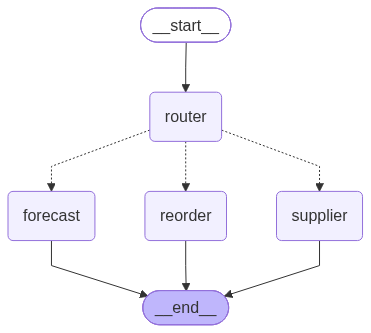

In [24]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))